In [ ]:
pip install pandas matplotlib

In [ ]:
#Create a Sample SQLite Database

In [2]:
import sqlite3
# Connect to (or create) the database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


# Create a sample 'sales' table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert some sample data
sample_data = [
    ("Apples", 10, 0.5),
    ("Bananas", 5, 0.3),
    ("Oranges", 8, 0.7),
    ("Apples", 6, 0.5),
    ("Bananas", 9, 0.3),
    ("Oranges", 7, 0.7),
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()


#Explanation:

A table called sales is created with product, quantity, and price.

Sample rows are inserted to simulate a tiny sales dataset.



In [ ]:
#Write Python Script to Query and Analyze the Data

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Step 1: Connect to the database
conn = sqlite3.connect("sales_data.db")

In [5]:
# Step 2: Define and run SQL query
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)


In [6]:
# Step 3: Close the connection
conn.close()


In [7]:
# Step 4: Print the result
print("Sales Summary:\n", df)


Sales Summary:
    product  total_qty  revenue
0   Apples         16      8.0
1  Bananas         14      4.2
2  Oranges         15     10.5


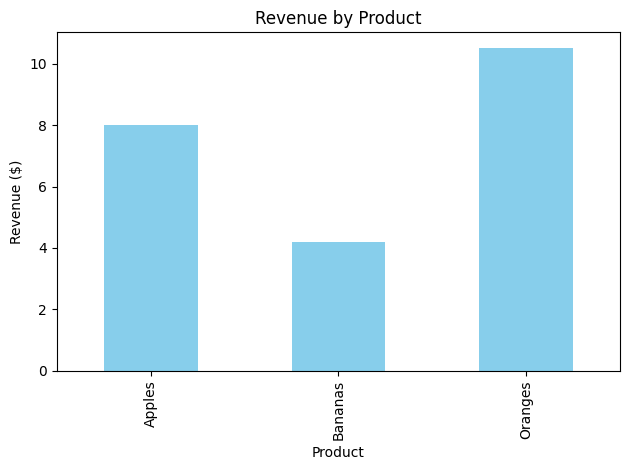

In [8]:
# Step 5: Plot a bar chart for revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()
plt.show()

# Optional: Save the chart as image
# plt.savefig("sales_chart.png")


Explanation:

The SQL query groups data by product and calculates:

Total quantity sold

Total revenue (quantity * price)

Results are loaded into a Pandas DataFrame.

A bar chart shows revenue by product.